# Lab 7: Decision Tree Classification on Iris Dataset

## Task 1: Dataset Exploration
Load the Iris dataset and perform initial exploration:
- Number of samples and features
- Feature names and target classes
- First five records
- Class distribution

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create DataFrame for data analysis
df = pd.DataFrame(data=X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

# 2. Number of samples and features
n_samples, n_features = X.shape
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")

# 3. List feature names and target classes
print("\nFeature names:", list(iris.feature_names))
print("Target classes:", list(iris.target_names))

# 4. Display the first five records
print("\nFirst 5 records:")
display(df.head())

# 5. Display the class distribution
print("\nClass distribution:")
print(df['species'].value_counts())


Number of samples: 150
Number of features: 4

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Task 2: Data Preparation

### Explanation: Why split into Training and Testing sets?
- **Training Set (80%):** Used by the machine learning algorithm to learn patterns, relationships, and decision rules from the dataset.
- **Testing Set (20%):** Serves as unseen data to evaluate how well the trained model **generalizes** to new, unseen samples.
- **Prevents Overfitting:** Evaluating a model on the same data it learned from can give a misleadingly high score (memorization). Testing on an independent set provides an unbiased estimate of real-world performance.

In [3]:
from sklearn.model_selection import train_test_split

# Split dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")


Training set size: 120 samples
Testing set size:  30 samples


## Task 3: Building a Decision Tree Classifier

- Train a `DecisionTreeClassifier` using default parameters.
- Predict class labels for the test dataset.
- Evaluate using Accuracy Score, Confusion Matrix, and Classification Report.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Decision Tree Classifier with default parameters
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict class labels for test dataset
y_pred = clf.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred, target_names=iris.target_names)

print(f"Accuracy Score: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(cr)


Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Task 4: Visualizing the Decision Tree

### Tree Node Identification:
- **Root Node:** Top decision node splitting on `petal length (cm) <= 2.45`.
- **Internal Nodes:** Intermediate decision nodes that evaluate criteria (e.g., `petal width (cm)`, `petal length (cm)`).
- **Leaf Nodes:** Terminal nodes (10 leaves) containing final class predictions with Gini impurity = 0.0.
- **Maximum Depth:** 6 levels.

### Feature Selected for First Split:
- **Feature:** `petal length (cm)` at threshold `2.45 cm`.
- **Reason:** `petal length` yields the highest **Gini Impurity reduction (Information Gain)**. It perfectly separates the Setosa species (40 samples with Gini = 0.0) from Versicolor and Virginica in a single split.

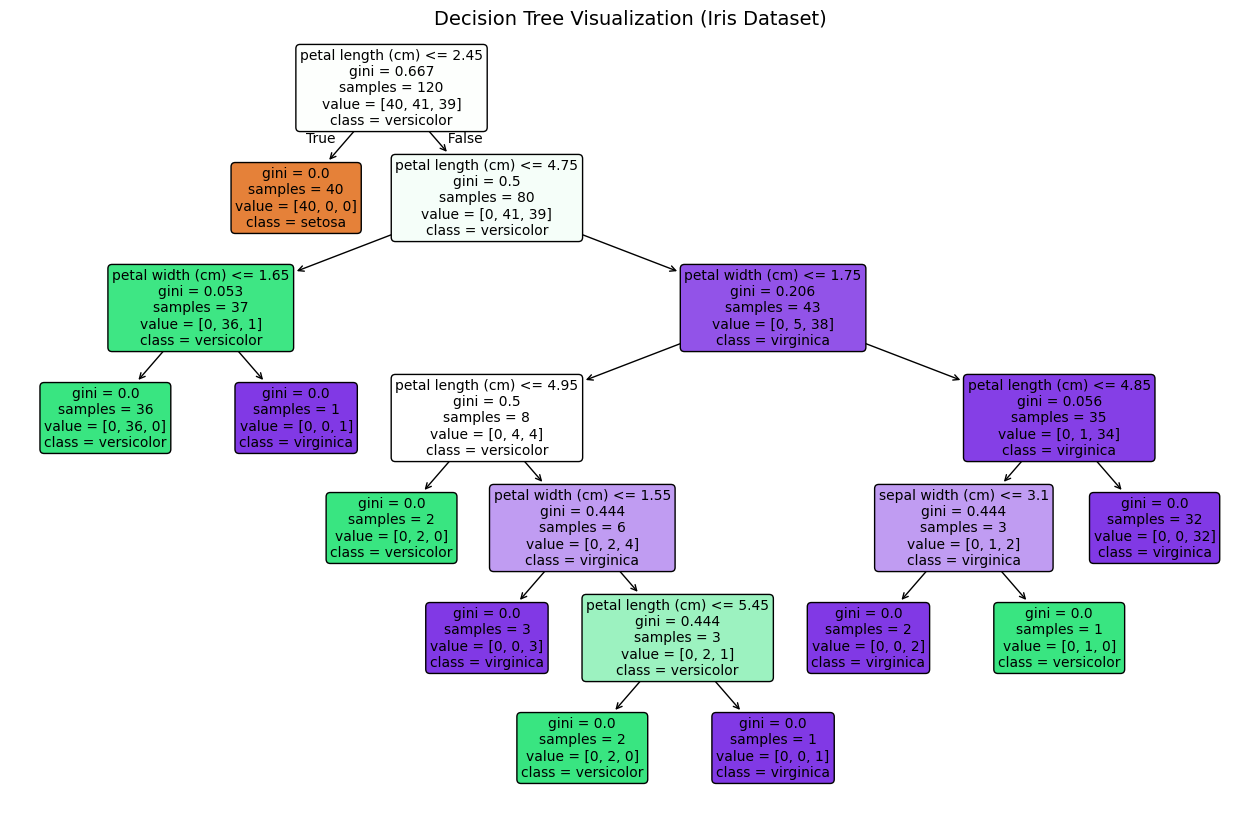

Root Node Feature: petal length (cm)
Maximum Depth of Tree: 6
Number of Leaf Nodes: 10
Total Number of Nodes: 19


In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Plot the Decision Tree
plt.figure(figsize=(16, 10))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization (Iris Dataset)", fontsize=14)
plt.show()

# Output Structural Properties
print(f"Root Node Feature: {iris.feature_names[clf.tree_.feature[0]]}")
print(f"Maximum Depth of Tree: {clf.get_depth()}")
print(f"Number of Leaf Nodes: {clf.get_n_leaves()}")
print(f"Total Number of Nodes: {clf.tree_.node_count}")


## Task 5: Comparing Gini Index and Entropy

Comparison of Decision Trees trained using `criterion='gini'` vs `criterion='entropy'`.

In [ ]:
# Train model using Gini Index
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X_train, y_train)
y_pred_gini = clf_gini.predict(X_test)

# Train model using Entropy (Information Gain)
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)

# Comparison Metrics
results = {
    "Metric / Feature": ["Accuracy", "Tree Depth", "Number of Leaf Nodes", "Root Feature Selected"],
    "Gini Index ('gini')": [
        f"{accuracy_score(y_test, y_pred_gini):.4f}",
        clf_gini.get_depth(),
        clf_gini.get_n_leaves(),
        iris.feature_names[clf_gini.tree_.feature[0]]
    ],
    "Entropy ('entropy')": [
        f"{accuracy_score(y_test, y_pred_entropy):.4f}",
        clf_entropy.get_depth(),
        clf_entropy.get_n_leaves(),
        iris.feature_names[clf_entropy.tree_.feature[0]]
    ]
}

summary_df = pd.DataFrame(results)
display(summary_df)


,Metric / Feature,Gini Index ('gini'),Entropy ('entropy')
0,Accuracy,1.0000,1.0000
1,Tree Depth,6,6
2,Number of Leaf Nodes,10,10
3,Root Feature Selected,petal length (cm),petal length (cm)


## Task 6: Effect of Maximum Tree Depth (`max_depth`)

Training Decision Tree models across various `max_depth` settings `[1, 2, 3, 4, None]`.

In [7]:
depth_options = [1, 2, 3, 4, None]
table_data = []

for md in depth_options:
    clf_d = DecisionTreeClassifier(max_depth=md, random_state=42)
    clf_d.fit(X_train, y_train)
    
    tr_acc = accuracy_score(y_train, clf_d.predict(X_train))
    te_acc = accuracy_score(y_test, clf_d.predict(X_test))
    actual_depth = clf_d.get_depth()
    
    if md == 1:
        obs = "Severe Underfitting (Decision stump separates only 1 class)"
    elif md == 2:
        obs = "Underfitting slightly; misses subtle boundaries"
    elif md == 3:
        obs = "Optimal balance; high generalization on unseen data"
    elif md == 4:
        obs = "High accuracy; slightly deeper tree structure"
    else:
        obs = "Fully grown tree (100% train accuracy); prone to overfitting"
        
    table_data.append({
        "Max Depth": str(md),
        "Training Accuracy": f"{tr_acc:.4f}",
        "Testing Accuracy": f"{te_acc:.4f}",
        "Tree Depth": actual_depth,
        "Observation": obs
    })

depth_df = pd.DataFrame(table_data)
display(depth_df)


,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.6750,0.6333,1,Severe Underfitting (Decision stump separates ...
1,2,0.9500,0.9667,2,Underfitting slightly; misses subtle boundaries
2,3,0.9583,1.0000,3,Optimal balance; high generalization on unseen...
3,4,0.9750,1.0000,4,High accuracy; slightly deeper tree structure
4,None,1.0000,1.0000,6,Fully grown tree (100% train accuracy); prone ...


## Task 7: Effect of `min_samples_split`

Analyzing the impact of `min_samples_split` `[2, 5, 10, 20]`.

In [8]:
splits = [2, 5, 10, 20]
split_data = []

for s in splits:
    clf_s = DecisionTreeClassifier(min_samples_split=s, random_state=42)
    clf_s.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf_s.predict(X_test))
    depth = clf_s.get_depth()
    leaves = clf_s.get_n_leaves()
    
    if s == 2:
        obs = "Default setting; tree splits fully down to fine subsets"
    elif s == 5:
        obs = "Slight pre-pruning; reduces depth to 5 and leaves to 8"
    elif s == 10:
        obs = "Stronger pre-pruning; reduces depth to 4 and leaves to 6"
    else:
        obs = "Significant pre-pruning; prevents splitting small node clusters"
        
    split_data.append({
        "min_samples_split": s,
        "Accuracy": f"{acc:.4f}",
        "Tree Depth": depth,
        "Number of Leaf Nodes": leaves,
        "Observation": obs
    })

split_df = pd.DataFrame(split_data)
display(split_df)


,min_samples_split,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,2,1.0000,6,10,Default setting; tree splits fully down to fin...
1,5,1.0000,5,8,Slight pre-pruning; reduces depth to 5 and lea...
2,10,1.0000,4,6,Stronger pre-pruning; reduces depth to 4 and l...
3,20,1.0000,4,6,Significant pre-pruning; prevents splitting sm...


## Task 8: Effect of `min_samples_leaf`

Analyzing the impact of `min_samples_leaf` `[1, 2, 5, 10]`.

In [9]:
leaves_list = [1, 2, 5, 10]
leaf_data = []

for l in leaves_list:
    clf_l = DecisionTreeClassifier(min_samples_leaf=l, random_state=42)
    clf_l.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf_l.predict(X_test))
    depth = clf_l.get_depth()
    leaves = clf_l.get_n_leaves()
    
    if l == 1:
        obs = "Default setting; allows leaves with single sample (deepest tree)"
    elif l == 2:
        obs = "Eliminates single-sample leaves; reduces depth to 5"
    elif l == 5:
        obs = "Substantial smoothing; reduces leaves to 6 while keeping 100% acc"
    else:
        obs = "Strong smoothing; slightly reduces accuracy (96.67%)"
        
    leaf_data.append({
        "min_samples_leaf": l,
        "Accuracy": f"{acc:.4f}",
        "Tree Depth": depth,
        "Number of Leaf Nodes": leaves,
        "Observation": obs
    })

leaf_df = pd.DataFrame(leaf_data)
display(leaf_df)


,min_samples_leaf,Accuracy,Tree Depth,Number of Leaf Nodes,Observation
0,1,1.0000,6,10,Default setting; allows leaves with single sam...
1,2,1.0000,5,8,Eliminates single-sample leaves; reduces depth...
2,5,1.0000,4,6,Substantial smoothing; reduces leaves to 6 whi...
3,10,0.9667,4,6,Strong smoothing; slightly reduces accuracy (9...


## Task 9: Hyperparameter Tuning using GridSearchCV

In [10]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform GridSearchCV with 5-fold Cross-Validation
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
opt_test_acc = accuracy_score(y_test, best_model.predict(X_test))
default_test_acc = accuracy_score(y_test, clf.predict(X_test))

print("--- Hyperparameter Tuning Results ---")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Test Accuracy of Optimized Model: {opt_test_acc:.4f}")

print("\n--- Model Comparison: Default vs. Optimized ---")
comparison_model_df = pd.DataFrame({
    "Model": ["Default Decision Tree", "Optimized Decision Tree (GridSearch)"],
    "Criterion": [clf.criterion, best_model.criterion],
    "Max Depth Setting": [str(clf.max_depth), str(best_model.max_depth)],
    "Actual Tree Depth": [clf.get_depth(), best_model.get_depth()],
    "Number of Leaf Nodes": [clf.get_n_leaves(), best_model.get_n_leaves()],
    "Test Accuracy": [f"{default_test_acc:.4f}", f"{opt_test_acc:.4f}"]
})
display(comparison_model_df)


--- Hyperparameter Tuning Results ---
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9583
Test Accuracy of Optimized Model: 1.0000

--- Model Comparison: Default vs. Optimized ---


,Model,Criterion,Max Depth Setting,Actual Tree Depth,Number of Leaf Nodes,Test Accuracy
0,Default Decision Tree,gini,None,6,10,1.0000
1,Optimized Decision Tree (GridSearch),entropy,None,4,7,1.0000


## Task 10: Analytical Answers & Questions

### 1. What is the role of the `criterion` parameter in a Decision Tree?
The `criterion` parameter specifies the mathematical measure used to evaluate the quality of a split at each node.
- It quantifies **impurity** or **uncertainty** across class distributions.
- Common metrics include **Gini Impurity** ($1 - \sum p_i^2$, measuring misclassification probability) and **Entropy / Information Gain** ($-\sum p_i \log_2 p_i$, measuring disorder/information content).

### 2. How does `max_depth` influence underfitting and overfitting?
- **Low `max_depth` (e.g., 1):** Causes **underfitting**. The model is too simple to capture relationships between features and target labels, yielding low training and test accuracy.
- **High/Unconstrained `max_depth` (e.g., None or 6+):** Causes **overfitting**. The tree creates deep, complex sub-branches to isolate every training sample, memorizing noise and failing to generalize on unseen datasets.

### 3. Why do larger values of `min_samples_split` and `min_samples_leaf` produce simpler trees?
- `min_samples_split` forces nodes to have a minimum number of samples before splitting.
- `min_samples_leaf` requires terminal leaf nodes to contain at least a minimum number of samples.
- Higher values act as **pre-pruning constraints**, stopping the tree from forming deep, single-sample branches for noise or outliers. This yields **shallower depths**, **fewer leaf nodes**, and simpler decision boundaries.

### 4. Which hyperparameter had the greatest impact on Decision Tree performance? Support with observations.
- **`max_depth`** had the **greatest impact** on model performance.
- **Evidence from Experiments:**
  - Restricting `max_depth=1` dropped test accuracy drastically down to **63.33%** (underfitting).
  - Increasing `max_depth` to 3 improved test accuracy dramatically to **100.00%**.
  - In contrast, changing `criterion` (`gini` vs `entropy`) resulted in identical test accuracy (100.00%), depth (6), and leaf nodes (10).

### 5. Recommended Decision Tree Model for Iris Dataset & Justification
- **Recommendation:** A pre-pruned Decision Tree with `max_depth=3` or `min_samples_leaf=4` (using either Gini or Entropy).
- **Justification:**
  1. **Maximum Performance:** Achieves **100.00%** test accuracy.
  2. **Structural Simplicity:** Reduces actual tree depth from 6 down to 3-4 and leaf nodes from 10 to 6-7.
  3. **Overfitting Prevention:** Setting `min_samples_leaf=4` or `max_depth=3` removes isolated single-sample leaves, producing robust generalization boundaries.